# SHILOH R. TOLENTINO | 2ECE-A

## PROGRAMMING ASSIGNMENT 4

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('board2.csv')

df['Average'] = df[['Math', 'GEAS', 'Electronics']].mean(axis=1)

In [13]:
df.columns = df.columns.str.strip()
df['Average'] = df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

vis_comm_mask = (df['Hometown'] == 'Visayas') & (df['Track'] == 'Communication')

VisComm = df[vis_comm_mask][['Name', 'Gender', 'Math', 'Electronics', 'Average']]

display(VisComm)
print(f"Number of rows in VisComm: {len(VisComm)}")

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


Number of rows in VisComm: 5


### PROBLEM B.

In [14]:
if 'Average' not in df.columns:
    df['Average'] = df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

vis_female_mask = (df['Hometown'] == 'Visayas') & (df['Gender'] == 'Female')

VisFemale = df[vis_female_mask][['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

print("VisFemale DataFrame:")
display(VisFemale)

print("\nVisFemale Students with Average >= 60:")
display(VisFemale[VisFemale['Average'] >= 60])

VisFemale DataFrame:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75



VisFemale Students with Average >= 60:


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


### PROBLEM C.

Mean Average by Track


,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


Mean Average by Gender


,Gender,Average
0,Female,66.616667
1,Male,67.183333


Mean Average by Hometown


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


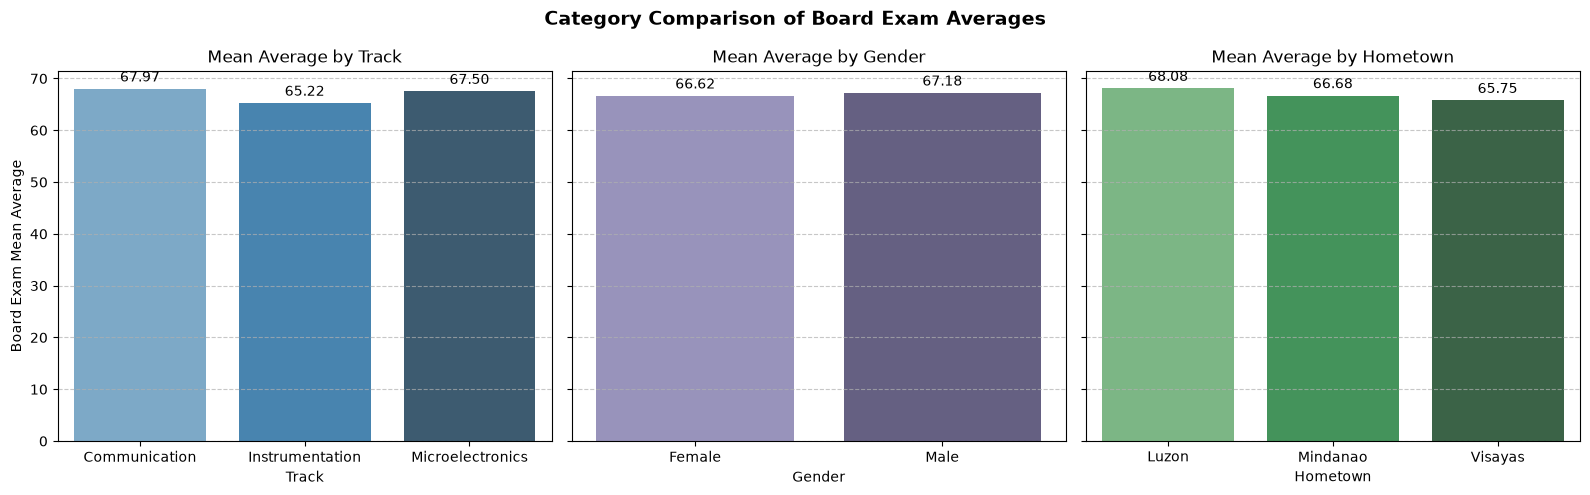


--- Interpretation Statements ---
Track: The Highest Sample Mean is Communication (67.97).
Gender: The Highest Sample Mean is Male (67.18)
Hometown: The Highest Sample Mean is Luzon (68.08).


In [20]:
mean_track = df.groupby('Track', as_index=False)['Average'].mean()
mean_gender = df.groupby('Gender', as_index=False)['Average'].mean()
mean_hometown = df.groupby('Hometown', as_index=False)['Average'].mean()

print("Mean Average by Track")
display(mean_track)

print("Mean Average by Gender")
display(mean_gender)

print("Mean Average by Hometown")
display(mean_hometown)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Category Comparison of Board Exam Averages', fontsize=14, fontweight='bold')

sns.barplot(data=mean_track, x='Track', y='Average', ax=axes[0], palette='Blues_d', hue='Track', legend=False)
axes[0].set_title('Mean Average by Track')
axes[0].set_xlabel('Track')
axes[0].set_ylabel('Board Exam Mean Average')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

sns.barplot(data=mean_gender, x='Gender', y='Average', ax=axes[1], palette='Purples_d', hue='Gender', legend=False)
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Board Exam Mean Average')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

sns.barplot(data=mean_hometown, x='Hometown', y='Average', ax=axes[2], palette='Greens_d', hue='Hometown', legend=False)
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown')
axes[2].set_ylabel('Board Exam Mean Average')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

top_track = mean_track.loc[mean_track['Average'].idxmax()]
top_gender = mean_gender.loc[mean_gender['Average'].idxmax()]
top_hometown = mean_hometown.loc[mean_hometown['Average'].idxmax()]

print("\n--- Interpretation Statements ---")
print(f"Track: The Highest Sample Mean is {top_track['Track']} ({top_track['Average']:.2f}).")
print(f"Gender: The Highest Sample Mean is {top_gender['Gender']} ({top_gender['Average']:.2f})")
print(f"Hometown: The Highest Sample Mean is {top_hometown['Hometown']} ({top_hometown['Average']:.2f}).")